In [1]:
import torch

print("PyTorch Version :", torch.__version__)
print("GPU Available :", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU Name :", torch.cuda.get_device_name(0))

PyTorch Version : 2.11.0+cu128
GPU Available : True
GPU Name : Tesla T4


In [2]:
# Configure Kaggle API

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

print("Kaggle API configured successfully!")

Kaggle API configured successfully!


In [3]:
# Install Kaggle
!pip install -q kaggle

In [4]:
# Download the dataset
!kaggle datasets download -d paramaggarwal/fashion-product-images-small

Dataset URL: https://www.kaggle.com/datasets/paramaggarwal/fashion-product-images-small
License(s): MIT
100% 565M/565M [00:08<00:00, 71.0MB/s]



In [5]:
# Extract the dataset
!unzip -q fashion-product-images-small.zip

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [6]:
import os

print(os.listdir())

['.config', 'kaggle.json', 'myntradataset', 'styles.csv', 'images', 'fashion-product-images-small.zip', 'sample_data']


In [7]:
import pandas as pd

# Load the metadata
styles = pd.read_csv("styles.csv", on_bad_lines="skip")

# Display first 5 rows
styles.head()

,id,gender,masterCategory,subCategory,articleType,baseColour,season,year,usage,productDisplayName
0,15970,Men,Apparel,Topwear,Shirts,Navy Blue,Fall,2011.0,Casual,Turtle Check Men Navy Blue Shirt
1,39386,Men,Apparel,Bottomwear,Jeans,Blue,Summer,2012.0,Casual,Peter England Men Party Blue Jeans
2,59263,Women,Accessories,Watches,Watches,Silver,Winter,2016.0,Casual,Titan Women Silver Watch
3,21379,Men,Apparel,Bottomwear,Track Pants,Black,Fall,2011.0,Casual,Manchester United Men Solid Black Track Pants
4,53759,Men,Apparel,Topwear,Tshirts,Grey,Summer,2012.0,Casual,Puma Men Grey T-shirt


In [8]:
print("Number of Products :", len(styles))

print("\nColumns:\n")
print(styles.columns)

print("\nMissing Values:\n")
print(styles.isnull().sum())

Number of Products : 44424

Columns:

Index(['id', 'gender', 'masterCategory', 'subCategory', 'articleType',
       'baseColour', 'season', 'year', 'usage', 'productDisplayName'],
      dtype='object')

Missing Values:

id                      0
gender                  0
masterCategory          0
subCategory             0
articleType             0
baseColour             15
season                 21
year                    1
usage                 317
productDisplayName      7
dtype: int64


Product Name : Turtle Check Men Navy Blue Shirt
Image Path : images/15970.jpg


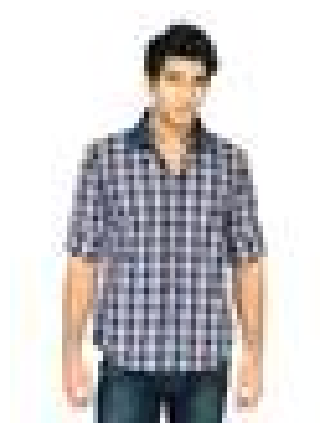

In [9]:
from PIL import Image
import matplotlib.pyplot as plt
import os

# Select the first product
product = styles.iloc[0]

# Get its ID
product_id = product["id"]

# Create image path
image_path = os.path.join("images", f"{product_id}.jpg")

print("Product Name :", product["productDisplayName"])
print("Image Path :", image_path)

# Display image
img = Image.open(image_path)

plt.figure(figsize=(4,6))
plt.imshow(img)
plt.axis("off")
plt.show()

In [10]:
!pip install -q transformers sentencepiece

In [11]:
from transformers import CLIPProcessor, CLIPModel

print("Loading CLIP model...")

model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

print("CLIP loaded successfully!")

Loading CLIP model...


config.json:   0%|          | 0.00/4.19k [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  605MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

...

vocab.json:   0%|          | 0.00/862k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/525k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.22M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

CLIP loaded successfully!


In [12]:
import torch
from PIL import Image
import os
from tqdm import tqdm

# Store image embeddings
image_embeddings = []
image_ids = []

# Number of images to process
NUM_IMAGES = 500

for _, row in tqdm(styles.head(NUM_IMAGES).iterrows(), total=NUM_IMAGES):

    image_path = os.path.join("images", f"{row['id']}.jpg")

    if os.path.exists(image_path):

        try:
            image = Image.open(image_path).convert("RGB")

            inputs = processor(images=image, return_tensors="pt")

            with torch.no_grad():
                embedding = model.get_image_features(**inputs)

            embedding = embedding / embedding.norm(dim=-1, keepdim=True)

            image_embeddings.append(embedding.squeeze())

            image_ids.append(row["id"])

        except:
            pass

print("Embeddings Generated :", len(image_embeddings))

100%|██████████| 500/500 [01:27<00:00,  5.75it/s]

Embeddings Generated : 0


In [13]:
import os

row = styles.iloc[0]

print("ID:", row["id"])
print("Type:", type(row["id"]))

image_path = os.path.join("images", f"{int(row['id'])}.jpg")

print("Image Path:", image_path)
print("Exists:", os.path.exists(image_path))

ID: 15970
Type: <class 'numpy.int64'>
Image Path: images/15970.jpg
Exists: True


In [14]:
import os

print(os.listdir("images")[:10])

['29126.jpg', '59631.jpg', '22619.jpg', '50997.jpg', '59691.jpg', '32355.jpg', '21833.jpg', '4706.jpg', '56559.jpg', '12470.jpg']


In [15]:
import torch
from PIL import Image
import os

row = styles.iloc[0]

image_path = os.path.join("images", f"{row['id']}.jpg")

image = Image.open(image_path).convert("RGB")

inputs = processor(images=image, return_tensors="pt")

with torch.no_grad():
    embedding = model.get_image_features(**inputs)

print("Embedding Shape:", embedding.shape)
print("Success!")

AttributeError: 'BaseModelOutputWithPooling' object has no attribute 'shape'

In [16]:
print(type(model))

<class 'transformers.models.clip.modeling_clip.CLIPModel'>


In [17]:
outputs = model.get_image_features(**inputs)
print(type(outputs))
print(outputs)

<class 'transformers.modeling_outputs.BaseModelOutputWithPooling'>
BaseModelOutputWithPooling(last_hidden_state=tensor([[[ 0.2177,  0.2518, -0.0492,  ..., -0.4101,  0.2336, -0.1099],
         [-0.1033,  0.1412, -0.5139,  ..., -0.2201,  0.2273,  0.4171],
         [-0.1385,  0.2368, -0.3497,  ..., -0.2035,  0.3045,  0.1925],
         ...,
         [-0.1182, -0.0567, -0.1738,  ..., -0.0322, -0.1303,  0.3330],
         [ 0.2015, -0.0357, -0.0906,  ...,  0.1478,  0.1543, -0.1910],
         [-0.0411,  0.0619, -0.4644,  ..., -0.4169,  0.0404, -0.0446]]],
       grad_fn=<AddBackward0>), pooler_output=tensor([[ 4.5576e-02,  2.5345e-01, -1.2212e-01,  3.6837e-02, -1.0669e-01,
          1.0585e-01, -5.6170e-02, -2.2421e-01,  2.5048e-01,  1.3485e-01,
          2.0783e-01,  4.4575e-01,  6.3402e-01,  4.6300e-01, -6.3646e-01,
          2.6845e-01,  1.4176e+00,  3.4850e-01,  2.4771e-01,  6.5100e-02,
          5.4763e-01, -3.8212e-01,  7.6502e-01, -6.0744e-01, -1.8963e-01,
          4.2901e-01,  3.1016e

In [18]:
import torch
from PIL import Image
import os
from tqdm import tqdm

image_embeddings = []
image_ids = []

NUM_IMAGES = 500

for _, row in tqdm(styles.head(NUM_IMAGES).iterrows(), total=NUM_IMAGES):

    image_path = os.path.join("images", f"{row['id']}.jpg")

    if os.path.exists(image_path):

        try:
            image = Image.open(image_path).convert("RGB")

            inputs = processor(images=image, return_tensors="pt")

            with torch.no_grad():
                outputs = model.get_image_features(**inputs)

                # Fix for newer transformers versions
                if hasattr(outputs, "pooler_output"):
                    embedding = outputs.pooler_output
                else:
                    embedding = outputs

            embedding = embedding / embedding.norm(dim=-1, keepdim=True)

            image_embeddings.append(embedding.squeeze())

            image_ids.append(row["id"])

        except Exception as e:
            print("Error:", e)

print("Embeddings Generated:", len(image_embeddings))

100%|██████████| 500/500 [01:33<00:00,  5.37it/s]

Embeddings Generated: 500


In [19]:
image_embeddings = torch.stack(image_embeddings)

print(image_embeddings.shape)

torch.Size([500, 512])


In [20]:
import torch

def search_products(query, top_k=5):

    # Convert text into CLIP embedding
    inputs = processor(text=[query], return_tensors="pt", padding=True)

    with torch.no_grad():
        text_embedding = model.get_text_features(**inputs)

    # Normalize
    text_embedding = text_embedding / text_embedding.norm(dim=-1, keepdim=True)

    # Cosine similarity
    similarity = image_embeddings @ text_embedding.T

    # Best matches
    top_indices = similarity.squeeze().topk(top_k).indices

    return top_indices

In [21]:
results = search_products("blue casual shirt")

print(results)

AttributeError: 'BaseModelOutputWithPooling' object has no attribute 'norm'

In [22]:
import torch

def search_products(query, top_k=5):

    # Convert text into CLIP input
    inputs = processor(text=[query], return_tensors="pt", padding=True)

    with torch.no_grad():
        outputs = model.get_text_features(**inputs)

        # Fix for newer transformers versions
        if hasattr(outputs, "pooler_output"):
            text_embedding = outputs.pooler_output
        else:
            text_embedding = outputs

    # Normalize
    text_embedding = text_embedding / text_embedding.norm(dim=-1, keepdim=True)

    # Cosine similarity
    similarity = image_embeddings @ text_embedding.T

    # Get top matches
    top_indices = similarity.squeeze().topk(top_k).indices

    return top_indices

In [23]:
outputs = model.get_text_features(**inputs)
print(type(outputs))

TypeError: CLIPModel.get_text_features() missing 1 required positional argument: 'input_ids'

In [24]:
query = "blue casual shirt"

text_inputs = processor(
    text=[query],
    return_tensors="pt",
    padding=True,
    truncation=True
)

print(text_inputs.keys())

KeysView({'input_ids': tensor([[49406,  1746, 10129,  2523, 49407]]), 'attention_mask': tensor([[1, 1, 1, 1, 1]])})


In [25]:
import transformers

print(transformers.__version__)

5.13.1


In [26]:
!pip install -q open_clip_torch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 31.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 4.5 MB/s eta 0:00:00


In [27]:
import open_clip
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"

# Load OpenCLIP model
model, _, preprocess = open_clip.create_model_and_transforms(
    "ViT-B-32",
    pretrained="laion2b_s34b_b79k"
)

tokenizer = open_clip.get_tokenizer("ViT-B-32")

model = model.to(device)
model.eval()

print("✅ OpenCLIP Loaded Successfully!")
print("Using Device:", device)

open_clip_model.safetensors: reconstructing file:   0%|          |  0.00B /  605MB            

open_clip_model.safetensors: downloading bytes:           |  0.00B            

✅ OpenCLIP Loaded Successfully!
Using Device: cuda


In [28]:
from PIL import Image
from tqdm import tqdm
import torch
import os

image_embeddings = []
image_ids = []

NUM_IMAGES = 500   # We'll use 500 for now

for _, row in tqdm(styles.head(NUM_IMAGES).iterrows(), total=NUM_IMAGES):

    image_path = os.path.join("images", f"{row['id']}.jpg")

    if not os.path.exists(image_path):
        continue

    try:
        image = preprocess(Image.open(image_path).convert("RGB")).unsqueeze(0).to(device)

        with torch.no_grad():
            embedding = model.encode_image(image)

        # Normalize
        embedding = embedding / embedding.norm(dim=-1, keepdim=True)

        image_embeddings.append(embedding.cpu().squeeze())
        image_ids.append(row["id"])

    except Exception as e:
        print(f"Skipping {row['id']}:", e)

print(f"✅ Generated {len(image_embeddings)} image embeddings")

100%|██████████| 500/500 [00:05<00:00, 98.53it/s] 

✅ Generated 500 image embeddings


In [29]:
image_embeddings = torch.stack(image_embeddings)

print(image_embeddings.shape)

torch.Size([500, 512])


In [30]:
def search_products(query, top_k=5):

    # Convert text into tokens
    text = tokenizer([query]).to(device)

    # Generate text embedding
    with torch.no_grad():
        text_embedding = model.encode_text(text)

    # Normalize
    text_embedding = text_embedding / text_embedding.norm(dim=-1, keepdim=True)

    # Move to CPU
    text_embedding = text_embedding.cpu()

    # Compute cosine similarity
    similarity = image_embeddings @ text_embedding.T

    # Get top-k indices
    top_indices = similarity.squeeze().topk(top_k).indices

    return top_indices

In [31]:
results = search_products("blue casual shirt")

print(results)

tensor([  0, 383, 284, 253, 466])


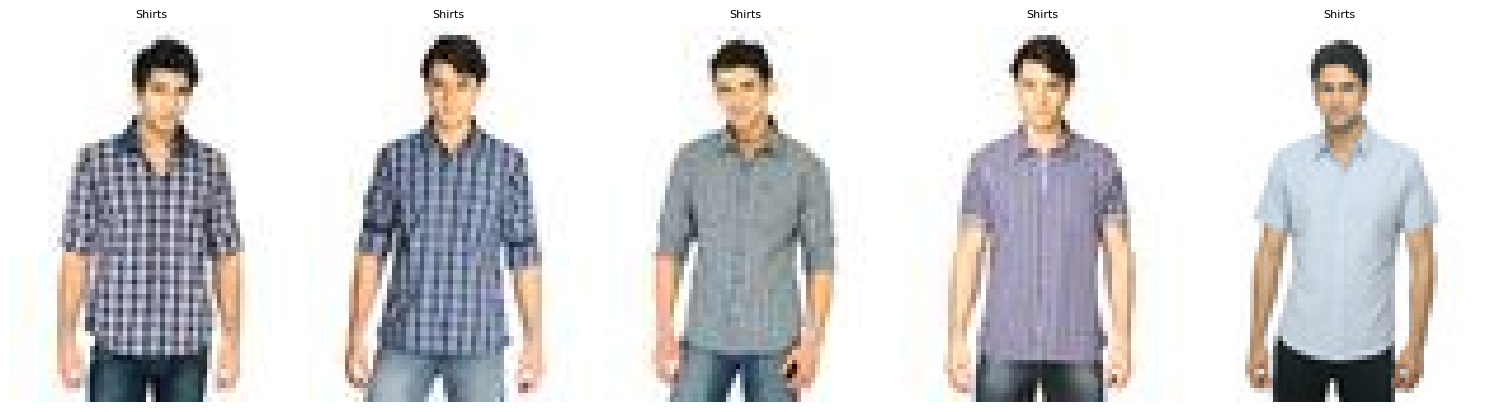

In [32]:
import matplotlib.pyplot as plt
from PIL import Image
import os

results = search_products("blue casual shirt")

plt.figure(figsize=(15,5))

for i, idx in enumerate(results):

    row = styles.iloc[idx.item()]

    img_path = os.path.join("images", f"{row['id']}.jpg")

    img = Image.open(img_path)

    plt.subplot(1, 5, i + 1)
    plt.imshow(img)
    plt.title(row["articleType"], fontsize=8)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [33]:
from sklearn.metrics.pairwise import cosine_similarity

# Compute similarity matrix
similarity_matrix = cosine_similarity(image_embeddings)

def find_similar_products(index, threshold=0.90):
    similarities = similarity_matrix[index]

    similar_products = []

    for i, score in enumerate(similarities):
        if i != index and score >= threshold:
            similar_products.append((i, score))

    # Sort by similarity score (highest first)
    similar_products = sorted(similar_products,
                              key=lambda x: x[1],
                              reverse=True)

    return similar_products

In [34]:
duplicates = find_similar_products(0)

print(duplicates[:5])

[(383, np.float32(0.92682433)), (284, np.float32(0.90743405))]


In [35]:
show_duplicates(0)

NameError: name 'show_duplicates' is not defined

In [37]:
import matplotlib.pyplot as plt
from PIL import Image
import os

def show_duplicates(index, threshold=0.90):

    duplicates = find_similar_products(index, threshold)

    if len(duplicates) == 0:
        print("No similar products found.")
        return

    plt.figure(figsize=(15,4))

    # Original Product
    row = styles.iloc[index]
    img = Image.open(os.path.join("images", f"{row['id']}.jpg"))

    plt.subplot(1, len(duplicates[:4]) + 1, 1)
    plt.imshow(img)
    plt.title("Original")
    plt.axis("off")

    # Similar Products
    for i, (idx, score) in enumerate(duplicates[:4], start=2):

        row = styles.iloc[idx]
        img = Image.open(os.path.join("images", f"{row['id']}.jpg"))

        plt.subplot(1, len(duplicates[:4]) + 1, i)
        plt.imshow(img)
        plt.title(f"{score:.2f}")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

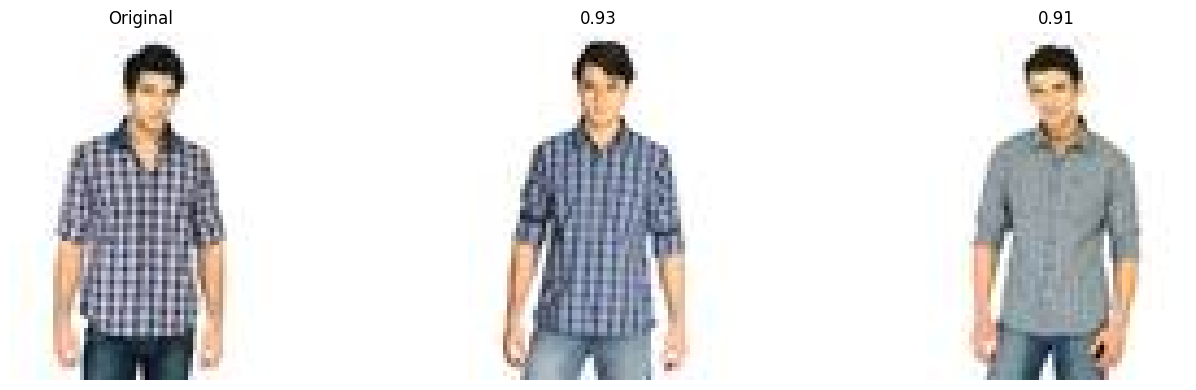

In [38]:
show_duplicates(0)

In [39]:
recommendation_rules = {

    "Shirts": ["Jeans", "Trousers", "Belts", "Watches"],

    "Tshirts": ["Jeans", "Casual Shoes", "Caps", "Backpacks"],

    "Jeans": ["Shirts", "Tshirts", "Casual Shoes", "Belts"],

    "Casual Shoes": ["Socks", "Backpacks", "Watches"],

    "Sports Shoes": ["Socks", "Track Pants", "Water Bottle"],

    "Kurtas": ["Leggings", "Sandals", "Handbags"],

    "Dresses": ["Handbags", "Heels", "Watches"]
}

In [40]:
print(styles["articleType"].value_counts().head(30))

articleType
Tshirts                  7067
Shirts                   3217
Casual Shoes             2845
Watches                  2542
Sports Shoes             2036
Kurtas                   1844
Tops                     1762
Handbags                 1759
Heels                    1323
Sunglasses               1073
Wallets                   936
Flip Flops                914
Sandals                   897
Briefs                    849
Belts                     813
Backpacks                 724
Socks                     686
Formal Shoes              637
Perfume and Body Mist     613
Jeans                     609
Shorts                    547
Trousers                  530
Flats                     500
Bra                       477
Dresses                   464
Sarees                    427
Earrings                  416
Deodorant                 347
Nail Polish               329
Lipstick                  315
Name: count, dtype: int64


In [41]:
print(styles["articleType"].value_counts().head(30))

articleType
Tshirts                  7067
Shirts                   3217
Casual Shoes             2845
Watches                  2542
Sports Shoes             2036
Kurtas                   1844
Tops                     1762
Handbags                 1759
Heels                    1323
Sunglasses               1073
Wallets                   936
Flip Flops                914
Sandals                   897
Briefs                    849
Belts                     813
Backpacks                 724
Socks                     686
Formal Shoes              637
Perfume and Body Mist     613
Jeans                     609
Shorts                    547
Trousers                  530
Flats                     500
Bra                       477
Dresses                   464
Sarees                    427
Earrings                  416
Deodorant                 347
Nail Polish               329
Lipstick                  315
Name: count, dtype: int64


In [42]:
print(styles["articleType"].value_counts().head(40))

articleType
Tshirts                  7067
Shirts                   3217
Casual Shoes             2845
Watches                  2542
Sports Shoes             2036
Kurtas                   1844
Tops                     1762
Handbags                 1759
Heels                    1323
Sunglasses               1073
Wallets                   936
Flip Flops                914
Sandals                   897
Briefs                    849
Belts                     813
Backpacks                 724
Socks                     686
Formal Shoes              637
Perfume and Body Mist     613
Jeans                     609
Shorts                    547
Trousers                  530
Flats                     500
Bra                       477
Dresses                   464
Sarees                    427
Earrings                  416
Deodorant                 347
Nail Polish               329
Lipstick                  315
Track Pants               304
Clutches                  290
Sweatshirts               28

In [43]:
recommendation_rules = {
    "Shirts": ["Jeans", "Belts", "Watches", "Casual Shoes"],
    "Tshirts": ["Jeans", "Casual Shoes", "Caps", "Backpacks"],
    "Jeans": ["Shirts", "Belts", "Casual Shoes"],
    "Casual Shoes": ["Socks", "Backpacks", "Watches"],
    "Sports Shoes": ["Socks", "Track Pants", "Watches"],
    "Kurtas": ["Sandals", "Handbags", "Earrings"],
    "Dresses": ["Heels", "Handbags", "Earrings"],
    "Formal Shoes": ["Belts", "Wallets", "Trousers"]
}

In [44]:
import random

def recommend_products(product_index):

    product = styles.iloc[product_index]
    article_type = product["articleType"]

    print("Input Product :", product["productDisplayName"])
    print("Article Type  :", article_type)

    if article_type not in recommendation_rules:
        print("\nNo recommendation rules available.")
        return None

    recommendations = recommendation_rules[article_type]

    recommended_rows = []

    for category in recommendations:

        matches = styles[styles["articleType"] == category]

        if len(matches) > 0:
            recommended_rows.append(matches.sample(1).iloc[0])

    return product, recommended_rows

In [45]:
import matplotlib.pyplot as plt
from PIL import Image
import os

def show_recommendations(product_index):

    result = recommend_products(product_index)

    if result is None:
        return

    product, recommended_rows = result

    plt.figure(figsize=(18,4))

    # Input Product
    img = Image.open(os.path.join("images", f"{product['id']}.jpg"))

    plt.subplot(1, len(recommended_rows)+1, 1)
    plt.imshow(img)
    plt.title("Input Product")
    plt.axis("off")

    # Recommended Products
    for i, row in enumerate(recommended_rows, start=2):

        img = Image.open(os.path.join("images", f"{row['id']}.jpg"))

        plt.subplot(1, len(recommended_rows)+1, i)
        plt.imshow(img)
        plt.title(row["articleType"], fontsize=8)
        plt.axis("off")

    plt.tight_layout()
    plt.show()

Input Product : Turtle Check Men Navy Blue Shirt
Article Type  : Shirts


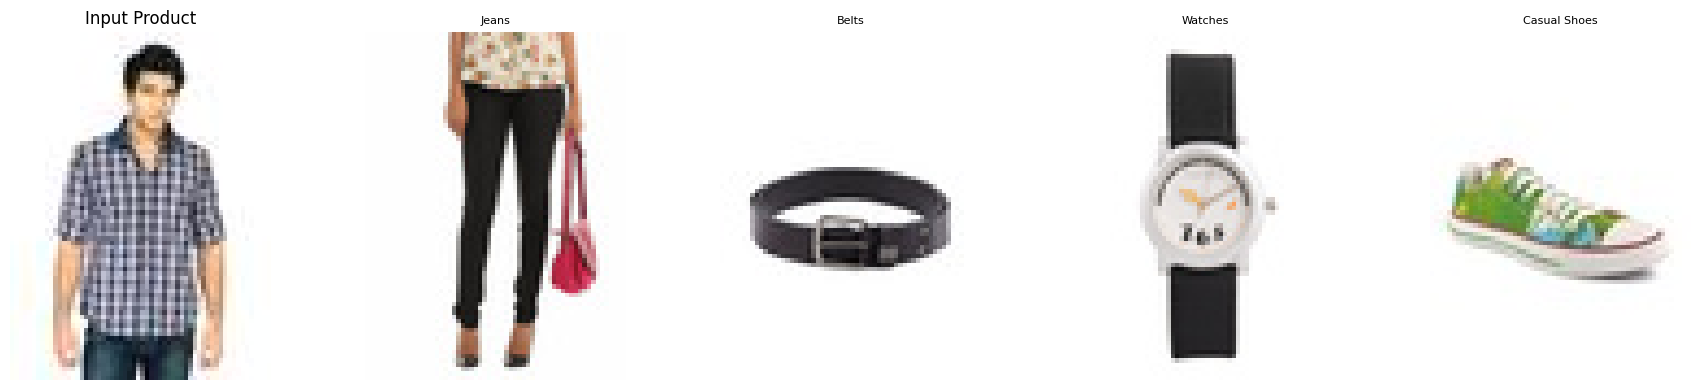

In [46]:
show_recommendations(0)

In [47]:
unique_indices = []
visited = set()

threshold = 0.90

for i in range(len(image_embeddings)):

    if i in visited:
        continue

    unique_indices.append(i)

    similar_products = find_similar_products(i, threshold)

    for idx, score in similar_products:
        visited.add(idx)

print("Total Products :", len(image_embeddings))
print("Unique Products:", len(unique_indices))

Total Products : 500
Unique Products: 484


In [48]:
unique_catalog = styles.iloc[unique_indices].copy()

print(unique_catalog[[
    "id",
    "productDisplayName",
    "articleType"
]].head(10))

      id                             productDisplayName  articleType
0  15970               Turtle Check Men Navy Blue Shirt       Shirts
1  39386             Peter England Men Party Blue Jeans        Jeans
2  59263                       Titan Women Silver Watch      Watches
3  21379  Manchester United Men Solid Black Track Pants  Track Pants
4  53759                          Puma Men Grey T-shirt      Tshirts
5   1855           Inkfruit Mens Chain Reaction T-shirt      Tshirts
6  30805               Fabindia Men Striped Green Shirt       Shirts
7  26960                  Jealous 21 Women Purple Shirt       Shirts
8  29114                       Puma Men Pack of 3 Socks        Socks
9  30039                         Skagen Men Black Watch      Watches


In [49]:
unique_catalog.to_csv(
    "unique_product_catalog.csv",
    index=False
)

print("✅ Unique catalog saved successfully!")

✅ Unique catalog saved successfully!
